In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy.interpolate import UnivariateSpline



# Set consistent style
plt.style.use('default')
fig_size_x = 7
fig_size_y = 4
plt.rcParams['font.size'] = 10

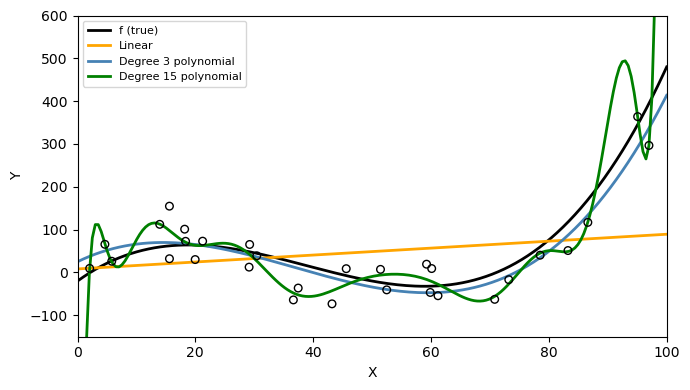

In [41]:
#| echo: false

np.random.seed(42)

n=30
# True function: third degree polynomial
def true_f(x):
    return 0.003*x**3 - 0.35*x**2 + 10*x - 20

x = np.linspace(0, 100, 200)
x_obs = np.random.uniform(0, 100, n)
y_obs = true_f(x_obs) + np.random.normal(0, 50, n)

# # Three fits
# Linear fit
lin_model = LinearRegression()
lin_model.fit(x_obs.reshape(-1, 1), y_obs)
y_linear = lin_model.predict(x.reshape(-1, 1))

# Degree 3 polynomial (matches true f)
coeffs3 = np.polyfit(x_obs, y_obs, 3)
y_poly3 = np.polyval(coeffs3, x)

# Degree 15 polynomial (overfitting)
t_min, t_max = x_obs.min(), x_obs.max()
x_norm = (x_obs - t_min) / (t_max - t_min)
x_line_norm = (x - t_min) / (t_max - t_min)
coeffs15 = np.polyfit(x_norm, y_obs, 15)
y_poly15 = np.polyval(coeffs15, x_line_norm)

plt.figure(figsize=(fig_size_x, fig_size_y))
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5)
plt.plot(x, true_f(x),  'k-',          linewidth=2, label='f (true)')
plt.plot(x, y_linear,   color='orange',    linewidth=2, label='Linear')
plt.plot(x, y_poly3,    color='steelblue', linewidth=2, label='Degree 3 polynomial')
plt.plot(x, y_poly15,   color='green',     linewidth=2, label='Degree 15 polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

In [36]:
print(y_poly15.min(), y_poly15.max())

-1577.2976060710491 4315.283636478209
